# PEBS trace analysis

In [3]:
WORKLOAD_RUNTIME_SECS=90

In [4]:
# imports
import matplotlib.pyplot as plt
import matplotlib.colors
import seaborn as sns
import numpy as np
import pandas as pd

## Data reading

In [5]:
df = pd.read_csv('../build/pebs_out.csv',
                header=None,
                 names=["tid", "ts", "addr"])

In [6]:
print(df)

                 tid            ts          addr
0             235220  8.239218e+13  1.399435e+14
1             235219  8.239221e+13  1.399434e+14
2             235219  8.239221e+13  9.479345e+13
3             235219  8.239221e+13  9.479345e+13
4             235219  8.239221e+13  9.479345e+13
...              ...           ...           ...
46036092  4294967295  8.248198e+13  1.399241e+14
46036093  4294967295  8.248198e+13  1.399241e+14
46036094  4294967295  8.248198e+13  1.399284e+14
46036095  4294967295  8.248198e+13  1.399241e+14
46036096    42949672           NaN           NaN

[46036097 rows x 3 columns]


## Data Cleaning

In [7]:
tids = set(df["tid"])
print(len(tids))

8


In [8]:
# data cleaning
# clean up timestamps

# Get the timestamp of the first row
first_ts = df['ts'].iloc[0]
print(f"First timestamp: {first_ts}")

# Calculate the relative timestamps
df['relative_ts'] = df['ts'] - first_ts

# Count rows with negative timestamps
negative_count = (df['relative_ts'] < 0).sum()
print(f"Number of rows with negative timestamps (to be ignored): {negative_count}")

# Filter out rows with negative timestamps
df_filtered = df[df['relative_ts'] >= 0]

# Replace the original timestamp with the relative one
# df_filtered['ts'] = df_filtered['relative_ts']
df_filtered.loc[:, 'ts'] = df_filtered['relative_ts']

# Drop the temporary column
df_filtered = df_filtered.drop('relative_ts', axis=1)
df = df_filtered

First timestamp: 82392175813992.0
Number of rows with negative timestamps (to be ignored): 0


In [9]:
print(df)

                 tid            ts          addr
0             235220  0.000000e+00  1.399435e+14
1             235219  3.775050e+07  1.399434e+14
2             235219  3.775638e+07  9.479345e+13
3             235219  3.775882e+07  9.479345e+13
4             235219  3.776401e+07  9.479345e+13
...              ...           ...           ...
46036091  4294967295  8.980828e+10  1.399327e+14
46036092  4294967295  8.980828e+10  1.399241e+14
46036093  4294967295  8.980829e+10  1.399241e+14
46036094  4294967295  8.980829e+10  1.399284e+14
46036095  4294967295  8.980830e+10  1.399241e+14

[46036096 rows x 3 columns]


In [10]:
# bin by 4kib
df.loc[:, 'page_4k'] = df['addr'] // 4096


# bin time (ms)
time_ms = WORKLOAD_RUNTIME_SECS * 1000
scale_factor_ms = df["ts"].iloc[-1] // time_ms
print("time scale factor", scale_factor_ms)
df.loc[:, 'ts_ms'] = df['ts'] // scale_factor_ms
df.loc[:, 'second'] = df['ts_ms'] // 1000


print(df)

time scale factor 997869.0
                 tid            ts          addr       page_4k    ts_ms  \
0             235220  0.000000e+00  1.399435e+14  3.416589e+10      0.0   
1             235219  3.775050e+07  1.399434e+14  3.416588e+10     37.0   
2             235219  3.775638e+07  9.479345e+13  2.314293e+10     37.0   
3             235219  3.775882e+07  9.479345e+13  2.314293e+10     37.0   
4             235219  3.776401e+07  9.479345e+13  2.314293e+10     37.0   
...              ...           ...           ...           ...      ...   
46036091  4294967295  8.980828e+10  1.399327e+14  3.416326e+10  90000.0   
46036092  4294967295  8.980828e+10  1.399241e+14  3.416117e+10  90000.0   
46036093  4294967295  8.980829e+10  1.399241e+14  3.416117e+10  90000.0   
46036094  4294967295  8.980829e+10  1.399284e+14  3.416221e+10  90000.0   
46036095  4294967295  8.980830e+10  1.399241e+14  3.416116e+10  90000.0   

          second  
0            0.0  
1            0.0  
2            0.

In [11]:
# filter page_4k ranges

df = df[df['page_4k'] <= 35000000000]
print(len(df))

46036095


In [12]:
# bin by 2mb
df.loc[:, 'page_2mb'] = df['addr'] // 2097152
df.loc[:, 'page_gb'] = df['addr'] // 1073741824

/tmp/ipykernel_247297/3881083544.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'page_2mb'] = df['addr'] // 2097152
/tmp/ipykernel_247297/3881083544.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'page_gb'] = df['addr'] // 1073741824


## Plot time vs. page access

Aggregate memory accesses by different page sizes. Then, print them over time.

In [13]:
def plot_aggr_count(df, page_key):
    # Group by both the second and the page_4k, then count
    page_access_counts = df.groupby(['second', page_key]).size().reset_index(name='access_count')
    
    # Create a pivot table with page_4k as rows and seconds as columns
    pivot_counts = page_access_counts.pivot_table(
        index=page_key,
        columns='second',
        values='access_count',
        fill_value=0  # Replace NaN with 0 for pages not accessed in a given second
    )
    pivot_counts = pivot_counts.sort_index(ascending=False)
    
    # Apply log2 transformation to the access counts
    # Add a small constant (1) to avoid log(0) which is undefined
    log_counts = np.log2(pivot_counts + 1)
    
    plt.figure(figsize=(16, 8))
    
    # Use the log-transformed data for the heatmap
    heatmap = sns.heatmap(
        log_counts, 
        cmap='viridis', 
        cbar_kws={'label': 'Access Count (log₂ scale)'}
    )
    
    plt.xlabel('Time (s)')
    plt.ylabel(f'Page access ({page_key})')
    plt.title(f'Access Frequency ({page_key}) per Second (log₂ scale)')
    plt.tight_layout()
    
    return pivot_counts

second,0.0,1.0,2.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,...,81.0,82.0,83.0,84.0,85.0,86.0,87.0,88.0,89.0,90.0
page_gb,,,,,,,,,,,,,,,,,,,,,
130332.0,69.0,115.0,48.0,0.0,29.0,42.0,176.0,147.0,152.0,118.0,...,91.0,128.0,149.0,141.0,125.0,130.0,142.0,126.0,151.0,0.0
130331.0,0.0,0.0,0.0,0.0,1.0,22.0,67.0,79.0,76.0,61.0,...,72.0,67.0,78.0,69.0,6.0,70.0,77.0,66.0,70.0,0.0
130326.0,0.0,0.0,147.0,0.0,3261.0,146492.0,140354.0,139671.0,141542.0,139442.0,...,124266.0,139989.0,142509.0,145056.0,85401.0,145970.0,140124.0,139484.0,146831.0,39.0
130322.0,0.0,145.0,3.0,0.0,4232.0,152160.0,146444.0,146553.0,147588.0,145393.0,...,129677.0,144960.0,147993.0,150200.0,86970.0,151475.0,147361.0,145364.0,153002.0,37.0
130318.0,0.0,145.0,0.0,0.0,4392.0,156007.0,151084.0,151452.0,151618.0,149806.0,...,133467.0,149953.0,152667.0,153785.0,92697.0,155036.0,151304.0,150081.0,156991.0,37.0
130314.0,161.0,2.0,0.0,0.0,4514.0,152392.0,145766.0,145963.0,146933.0,145180.0,...,125509.0,145460.0,147965.0,150108.0,90755.0,150484.0,145991.0,145247.0,153233.0,27.0
88283.0,98.0,102.0,44.0,1.0,10.0,38.0,11.0,13.0,9.0,14.0,...,12.0,15.0,13.0,18.0,7.0,15.0,9.0,13.0,15.0,0.0


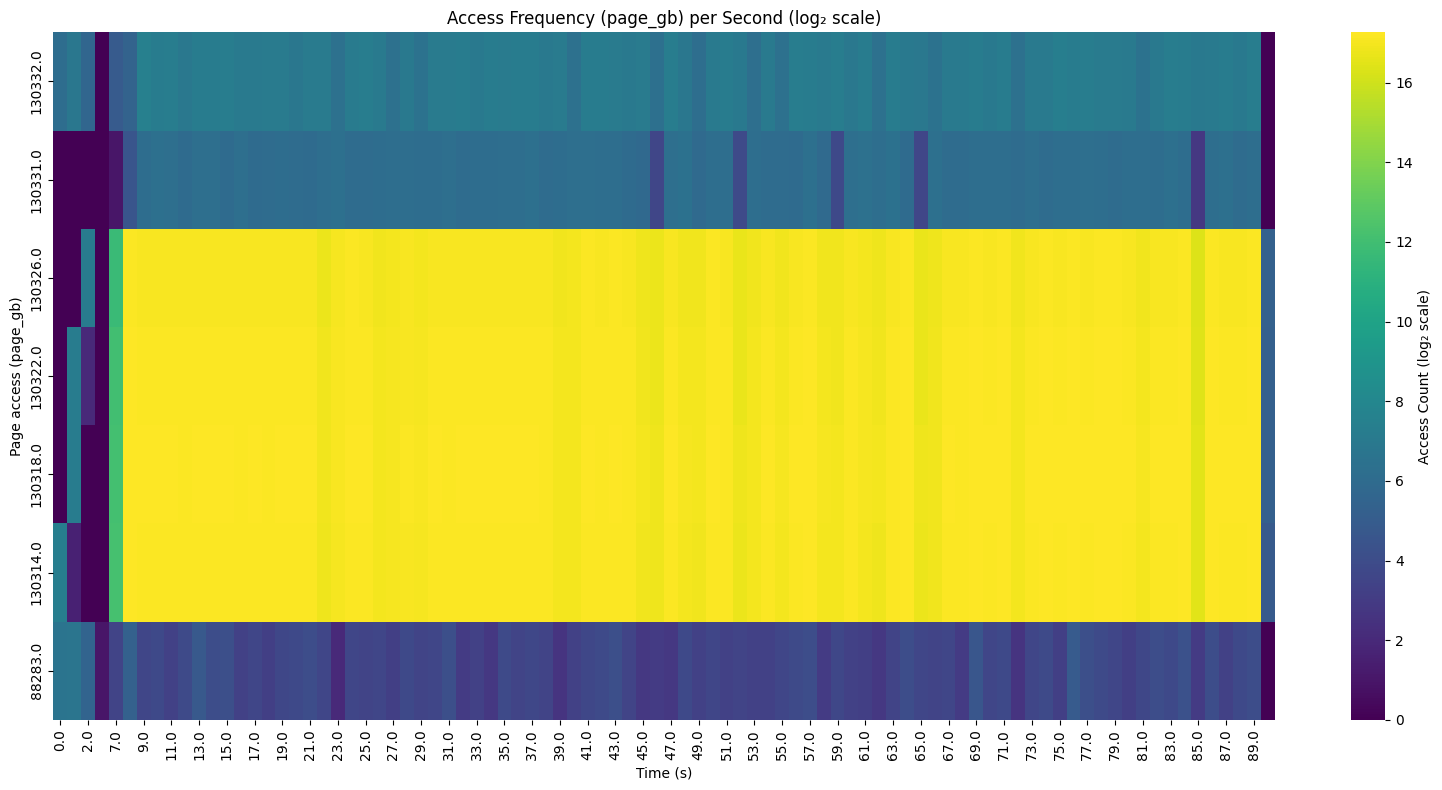

In [14]:
plot_aggr_count(df, 'page_gb')

second,0.0,1.0,2.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,...,81.0,82.0,83.0,84.0,85.0,86.0,87.0,88.0,89.0,90.0
page_2mb,,,,,,,,,,,,,,,,,,,,,
66730244.0,4.0,9.0,0.0,0.0,4.0,0.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66730243.0,0.0,0.0,0.0,0.0,0.0,2.0,6.0,2.0,2.0,1.0,...,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
66730241.0,21.0,45.0,21.0,0.0,7.0,0.0,5.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
66730240.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66730239.0,13.0,18.0,8.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45201212.0,6.0,14.0,10.0,0.0,0.0,3.0,0.0,3.0,1.0,4.0,...,2.0,1.0,2.0,4.0,0.0,1.0,1.0,2.0,0.0,0.0
45201210.0,1.0,5.0,6.0,0.0,0.0,3.0,0.0,3.0,2.0,0.0,...,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
45201041.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


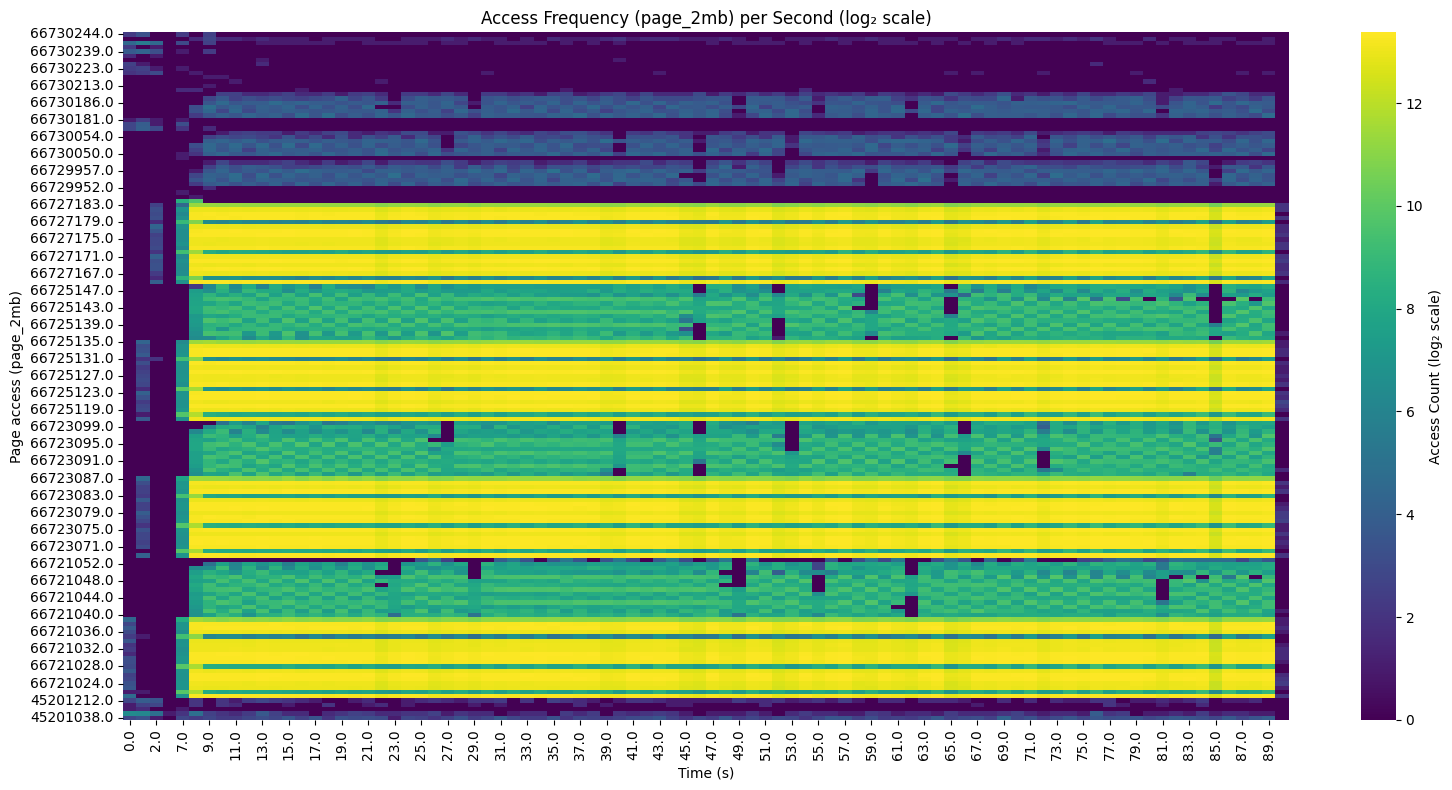

In [38]:
test_df = df[df["page_2mb"] > 0]
plot_aggr_count(test_df, 'page_2mb')

In [39]:
# # try plotting with sampling (hemem sampling rate)
# sample_df = df.sample(frac=0.0002, random_state=42)
# plot_aggr_count(sample_df, 'page_2mb')

second,0.0,1.0,2.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,...,81.0,82.0,83.0,84.0,85.0,86.0,87.0,88.0,89.0,90.0
page_4k,,,,,,,,,,,,,,,,,,,,,
3.416589e+10,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3.416589e+10,1.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3.416589e+10,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3.416589e+10,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3.416589e+10,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2.314293e+10,2.0,5.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2.314293e+10,2.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2.314293e+10,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


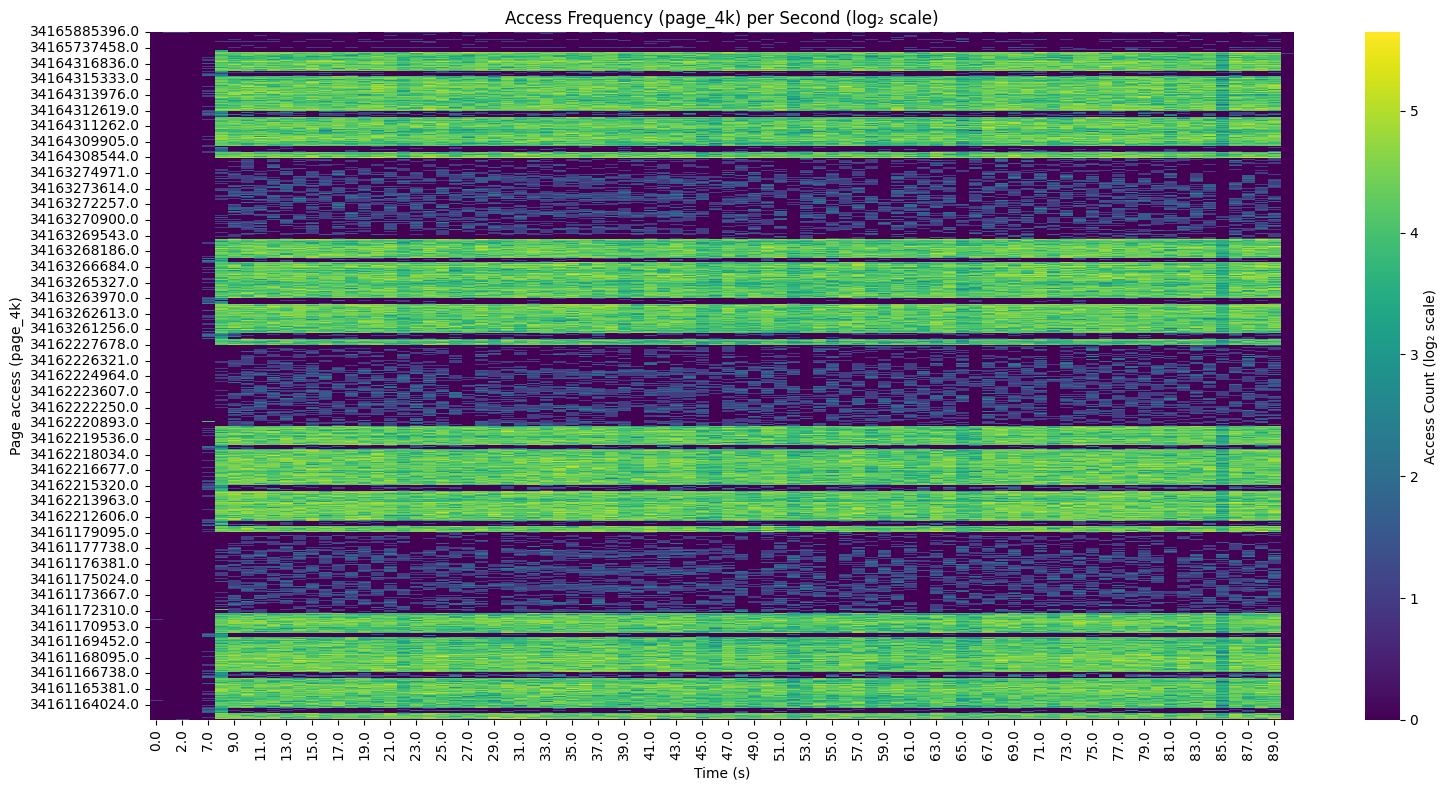

In [40]:
test_df_4k = df[df["page_4k"] > 0]
plot_aggr_count(test_df_4k, 'page_4k')

In [41]:
# test_df_4k = df[df["page_4k"] < 34279679633]
# plot_aggr_count(test_df_4k, 'page_4k')

## Plot page accesses (sampled vs. unsampled)

In [42]:
def analyze_page_access(df, page_key, sampling_rate=0.5, figsize=(20, 16)):
    """
    Analyze page access patterns in both original and sampled dataframes.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe with 'second' and page_key columns
    page_key : str, default='page_4k'
        Column name for the page identifier
    sampling_rate : float, default=0.5
        Rate at which to sample the data (0.1 = 10%, 0.5 = 50%, etc.)
    figsize : tuple, default=(20, 16)
        Figure size for the plot
        
    Returns:
    --------
    tuple: (original_pivot_counts, sampled_pivot_counts, difference_pivot)
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.gridspec as gridspec
    
    # Create a sampled dataframe
    sampled_df = df.sample(frac=sampling_rate, random_state=42)
    
    # Process original dataframe
    original_counts = df.groupby(['second', page_key]).size().reset_index(name='access_count')
    original_pivot = original_counts.pivot_table(
        index=page_key,
        columns='second',
        values='access_count',
        fill_value=0
    )
    original_pivot = original_pivot.sort_index(ascending=False)
    
    # Process sampled dataframe
    sampled_counts = sampled_df.groupby(['second', page_key]).size().reset_index(name='access_count')
    sampled_pivot = sampled_counts.pivot_table(
        index=page_key,
        columns='second',
        values='access_count',
        fill_value=0
    )
    
    # Ensure both pivots have the same indices and columns
    all_pages = sorted(set(original_pivot.index) | set(sampled_pivot.index))
    all_seconds = sorted(set(original_pivot.columns) | set(sampled_pivot.columns))
    
    # Reindex both pivots
    original_pivot = original_pivot.reindex(index=all_pages, columns=all_seconds, fill_value=0)
    sampled_pivot = sampled_pivot.reindex(index=all_pages, columns=all_seconds, fill_value=0)
    
    # Sort both pivots
    original_pivot = original_pivot.sort_index(ascending=False)
    sampled_pivot = sampled_pivot.sort_index(ascending=False)
    
    # Calculate the difference
    # Scale up the sampled data by the inverse of the sampling rate to make it comparable
    scaled_sampled_pivot = sampled_pivot
    
    # Difference pivot: 1 where original has data but sampled (scaled) has none
    # This highlights pages that were missed by sampling
    difference_pivot = pd.DataFrame(0, index=all_pages, columns=all_seconds)
    
    for idx in all_pages:
        for col in all_seconds:
            if original_pivot.loc[idx, col] > 0 and scaled_sampled_pivot.loc[idx, col] == 0:
                # Pages accessed in original but not in sampled (even after scaling)
                difference_pivot.loc[idx, col] = 1
    
    difference_pivot = difference_pivot.sort_index(ascending=False)
    
    # Plot the three heatmaps
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 1], hspace=0.4)
    
    # 1. Original Data Heatmap
    ax1 = plt.subplot(gs[0])
    log_original = np.log2(original_pivot + 1)
    sns.heatmap(
        log_original, 
        cmap='viridis', 
        cbar_kws={'label': 'Access Count (log₂ scale)'},
        ax=ax1
    )
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel(f'Page ({page_key})')
    ax1.set_title(f'Original Data: Access Frequency ({page_key}) per Second (log₂ scale)')
    
    # 2. Sampled Data Heatmap
    ax2 = plt.subplot(gs[1])
    log_sampled = np.log2(sampled_pivot + 1)
    sns.heatmap(
        log_sampled, 
        cmap='viridis', 
        cbar_kws={'label': 'Access Count (log₂ scale)'},
        ax=ax2
    )
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel(f'Page ({page_key})')
    ax2.set_title(f'Sampled Data (sampling={sampling_rate}): Access Frequency ({page_key}) per Second (log₂ scale)')
    
    # 3. Difference Heatmap
    ax3 = plt.subplot(gs[2])
    sns.heatmap(
        difference_pivot, 
        cmap='Reds', 
        cbar_kws={'label': 'Missed by Sampling (1=Yes, 0=No)'},
        ax=ax3
    )
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel(f'Page ({page_key})')
    ax3.set_title(f'Pages Accessed in Original but Missed in Sampled Data')
    
    plt.tight_layout()
    
    # Calculate some statistics about missed pages
    total_cells = original_pivot.size
    missed_cells = difference_pivot.sum().sum()
    missed_percentage = (missed_cells / total_cells) * 100
    
    # Count unique pages that were completely missed by sampling
    completely_missed_pages = []
    for page in all_pages:
        if original_pivot.loc[page].sum() > 0 and sampled_pivot.loc[page].sum() == 0:
            completely_missed_pages.append(page)
    
    print(f"Sampling rate: {sampling_rate}%")
    print(f"Total page-second combinations in original data: {total_cells}")
    print(f"Page-second combinations missed by sampling: {missed_cells} ({missed_percentage:.2f}%)")
    print(f"Number of pages completely missed by sampling: {len(completely_missed_pages)}")
    
    return original_pivot, sampled_pivot, difference_pivot

Sampling rate: 0.0002%
Total page-second combinations in original data: 14168
Page-second combinations missed by sampling: 6992 (49.35%)
Number of pages completely missed by sampling: 46


/tmp/ipykernel_234263/2672796304.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(second      0.0   1.0   2.0   6.0   7.0   8.0   9.0   10.0  11.0  12.0  ...  \
 page_2mb                                                                ...   
 66730244.0   4.0   9.0   0.0   0.0   4.0   0.0   5.0   0.0   0.0   0.0  ...   
 66730243.0   0.0   0.0   0.0   0.0   0.0   2.0   6.0   2.0   2.0   1.0  ...   
 66730241.0  21.0  45.0  21.0   0.0   7.0   0.0   5.0   0.0   0.0   0.0  ...   
 66730240.0   4.0   0.0   1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
 66730239.0  13.0  18.0   8.0   0.0   1.0   0.0   4.0   0.0   0.0   0.0  ...   
 ...          ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
 45201212.0   6.0  14.0  10.0   0.0   0.0   3.0   0.0   3.0   1.0   4.0  ...   
 45201210.0   1.0   5.0   6.0   0.0   0.0   3.0   0.0   3.0   2.0   0.0  ...   
 45201041.0   1.0   2.0   0.0   0.0   1.0   0.0   0.0   0.0   0.0   0.0  ...   
 45201039.0  84.0  72.0  27.0   1.0   3.0  28.0   5.0   3.0   2.0   4.0  ...   
 45201038.0   6.0   9.0   1.0   0.0   6.

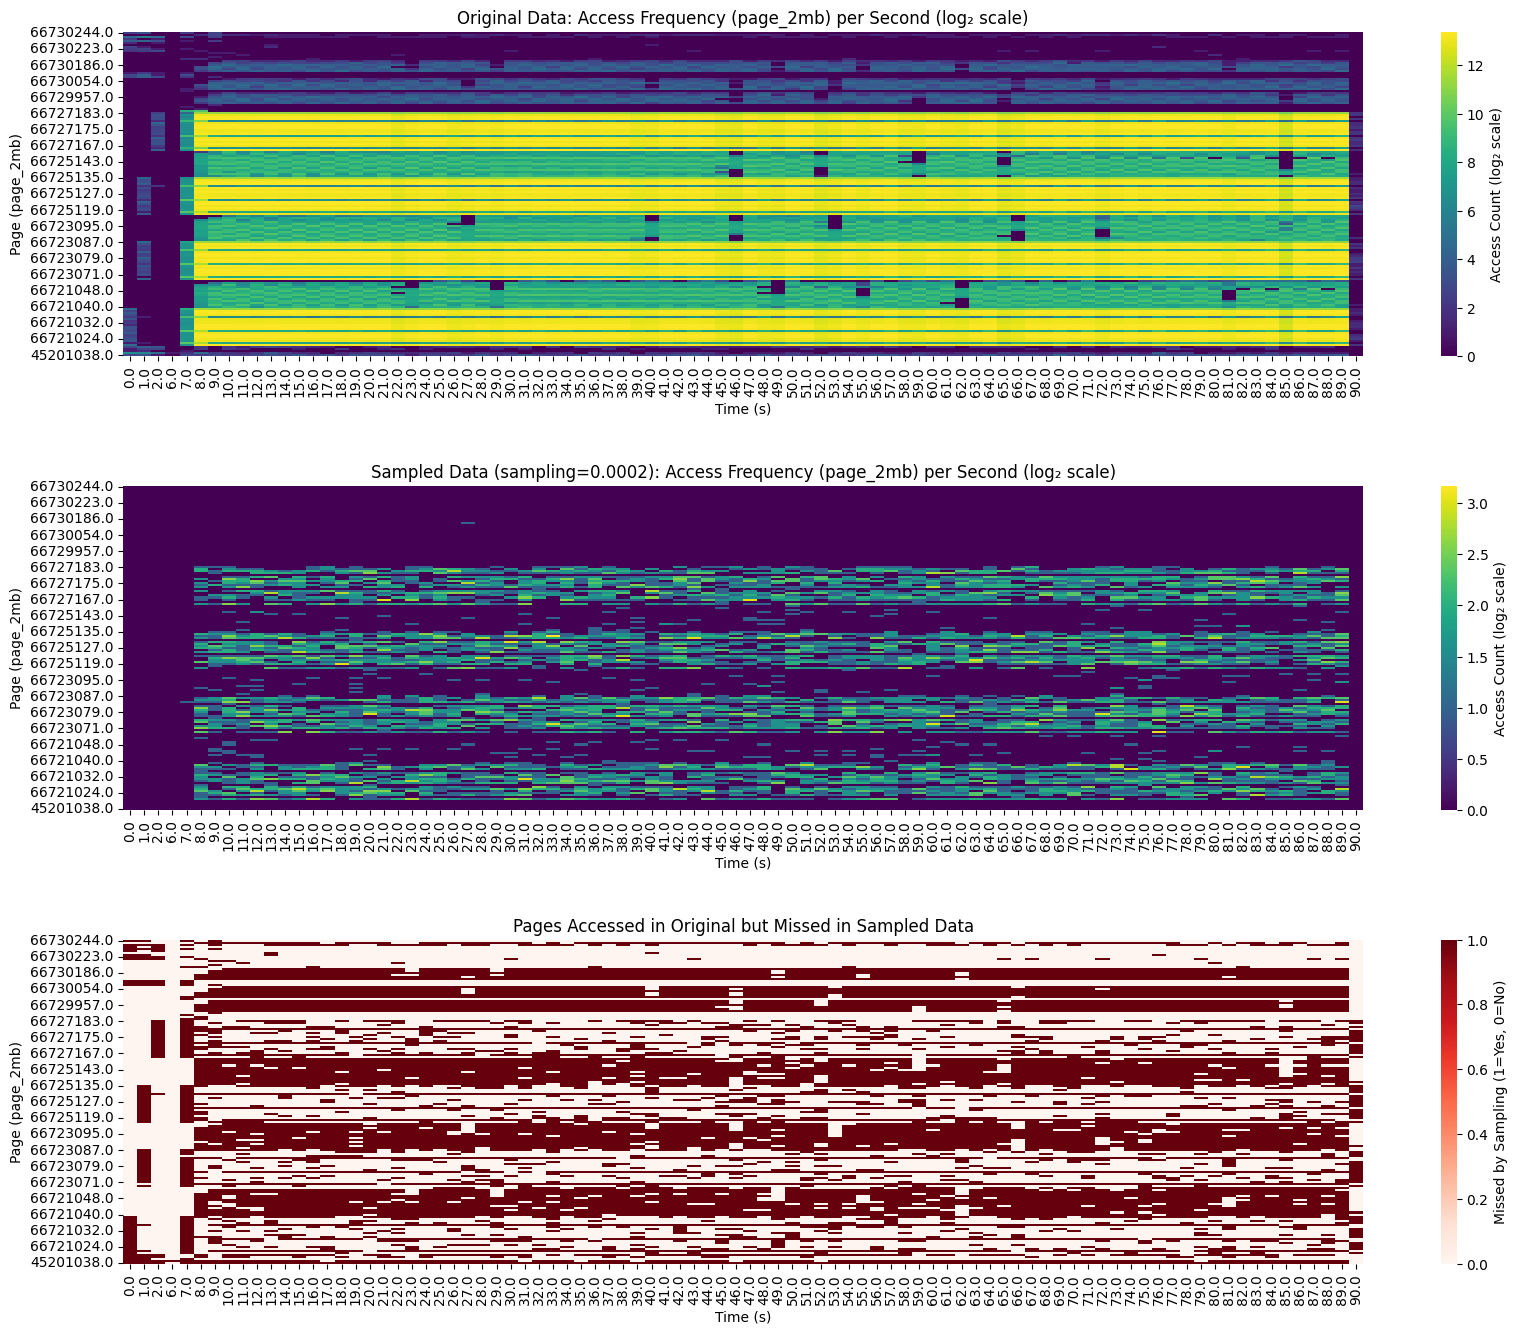

In [43]:
analyze_page_access(df, "page_2mb", sampling_rate=0.0002)

Sampling rate: 0.002%
Total page-second combinations in original data: 14168
Page-second combinations missed by sampling: 4302 (30.36%)
Number of pages completely missed by sampling: 26


/tmp/ipykernel_234263/2672796304.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(second      0.0   1.0   2.0   6.0   7.0   8.0   9.0   10.0  11.0  12.0  ...  \
 page_2mb                                                                ...   
 66730244.0   4.0   9.0   0.0   0.0   4.0   0.0   5.0   0.0   0.0   0.0  ...   
 66730243.0   0.0   0.0   0.0   0.0   0.0   2.0   6.0   2.0   2.0   1.0  ...   
 66730241.0  21.0  45.0  21.0   0.0   7.0   0.0   5.0   0.0   0.0   0.0  ...   
 66730240.0   4.0   0.0   1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
 66730239.0  13.0  18.0   8.0   0.0   1.0   0.0   4.0   0.0   0.0   0.0  ...   
 ...          ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
 45201212.0   6.0  14.0  10.0   0.0   0.0   3.0   0.0   3.0   1.0   4.0  ...   
 45201210.0   1.0   5.0   6.0   0.0   0.0   3.0   0.0   3.0   2.0   0.0  ...   
 45201041.0   1.0   2.0   0.0   0.0   1.0   0.0   0.0   0.0   0.0   0.0  ...   
 45201039.0  84.0  72.0  27.0   1.0   3.0  28.0   5.0   3.0   2.0   4.0  ...   
 45201038.0   6.0   9.0   1.0   0.0   6.

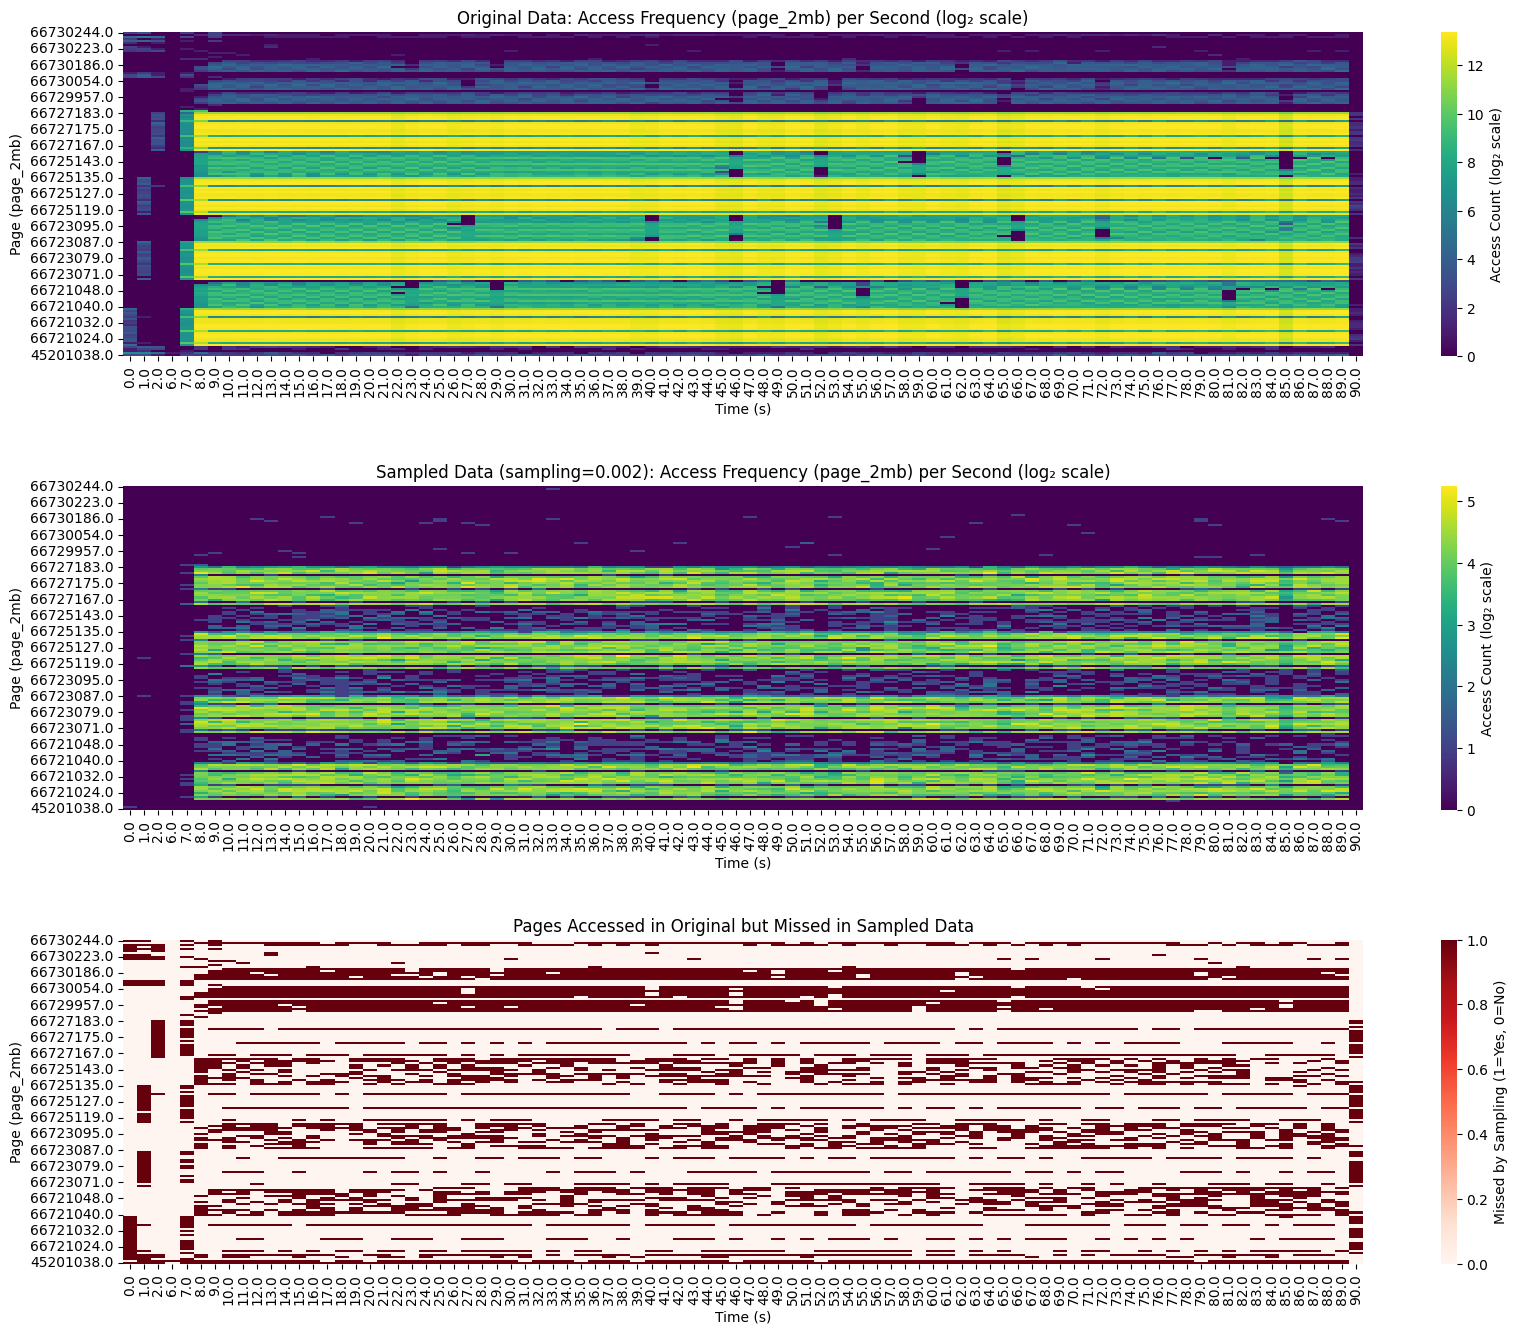

In [44]:
analyze_page_access(df, "page_2mb", sampling_rate=0.002)

## Plot skewness (sampled vs. unsampled)

In [45]:
def plot_skewness_single(df):
    # Group by 'second' and 'page_2mb' and count distinct 'page_4k' values
    distinct_counts = df.groupby(['second', 'page_2mb'])['page_4k'].nunique().reset_index()
    
    # Rename the column for clarity
    distinct_counts.rename(columns={'page_4k': 'distinct_4k_pages'}, inplace=True)
    
    # distinct_counts['skewness'] = 1 / distinct_counts['distinct_4k_pages']
    distinct_counts['skewness'] = distinct_counts['distinct_4k_pages']
    
    # Create a pivot table with seconds as rows, 2mb pages as columns, and skewness as values
    pivot_result = pd.pivot_table(distinct_counts, 
                                 values='skewness', 
                                 index='page_2mb',
                                 columns='second')
    pivot_result = pivot_result.sort_index(ascending=False)
    
    plt.figure(figsize=(16, 8))

    heatmap = sns.heatmap(
        pivot_result, 
        cmap='viridis', 
        cbar_kws={'label': '# 4KB pages accessed in 2MB page'}
    )

    plt.xlabel('Time (s)')
    plt.ylabel(f'2MB page')
    plt.title(f'Access uniformity (higher is more uniform)')
    plt.tight_layout()
    

In [46]:
def plot_skewness_comparison(df, sample_rate=0.5, random_state=42):
    """
    Plot two heatmaps side by side: the original heatmap and one based on a sampled dataframe.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The input dataframe with columns 'second', 'page_2mb', and 'page_4k'
    sample_rate : float, default=0.5
        The fraction of rows to sample from the original dataframe (0.0 to 1.0)
    random_state : int, default=42
        Random seed for reproducibility
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Create a sampled dataframe
    df_sampled = df.sample(frac=sample_rate, random_state=random_state)
    
    # Create a figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))
    
    # Helper function to create the heatmap data
    def create_heatmap_data(data):
        # Group by 'second' and 'page_2mb' and count distinct 'page_4k' values
        distinct_counts = data.groupby(['second', 'page_2mb'])['page_4k'].nunique().reset_index()
        
        # Rename the column for clarity
        distinct_counts.rename(columns={'page_4k': 'distinct_4k_pages'}, inplace=True)
        
        # Use distinct_4k_pages as the skewness measure
        distinct_counts['skewness'] = distinct_counts['distinct_4k_pages']
        
        # Create a pivot table with seconds as rows, 2mb pages as columns, and skewness as values
        pivot_result = pd.pivot_table(distinct_counts, 
                                     values='skewness', 
                                     index='page_2mb',
                                     columns='second')
        return pivot_result.sort_index(ascending=False)
    
    # Create heatmap data for both the original and sampled dataframes
    pivot_result_original = create_heatmap_data(df)
    pivot_result_sampled = create_heatmap_data(df_sampled)
    
    # Create the first heatmap (original data)
    sns.heatmap(
        pivot_result_original, 
        cmap='viridis', 
        cbar_kws={'label': '# 4KB pages accessed in 2MB page'},
        ax=ax1,
        vmax=512
    )
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('2MB page')
    ax1.set_title('Original: Access uniformity (higher is more uniform)')
    
    # Create the second heatmap (sampled data)
    sns.heatmap(
        pivot_result_sampled, 
        cmap='viridis', 
        cbar_kws={'label': '# 4KB pages accessed in 2MB page'},
        ax=ax2,
        vmax=512
    )
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('2MB page')
    ax2.set_title(f'Sampled (rate={sample_rate}): Access uniformity (higher is more uniform)')
    
    plt.tight_layout()
    return fig

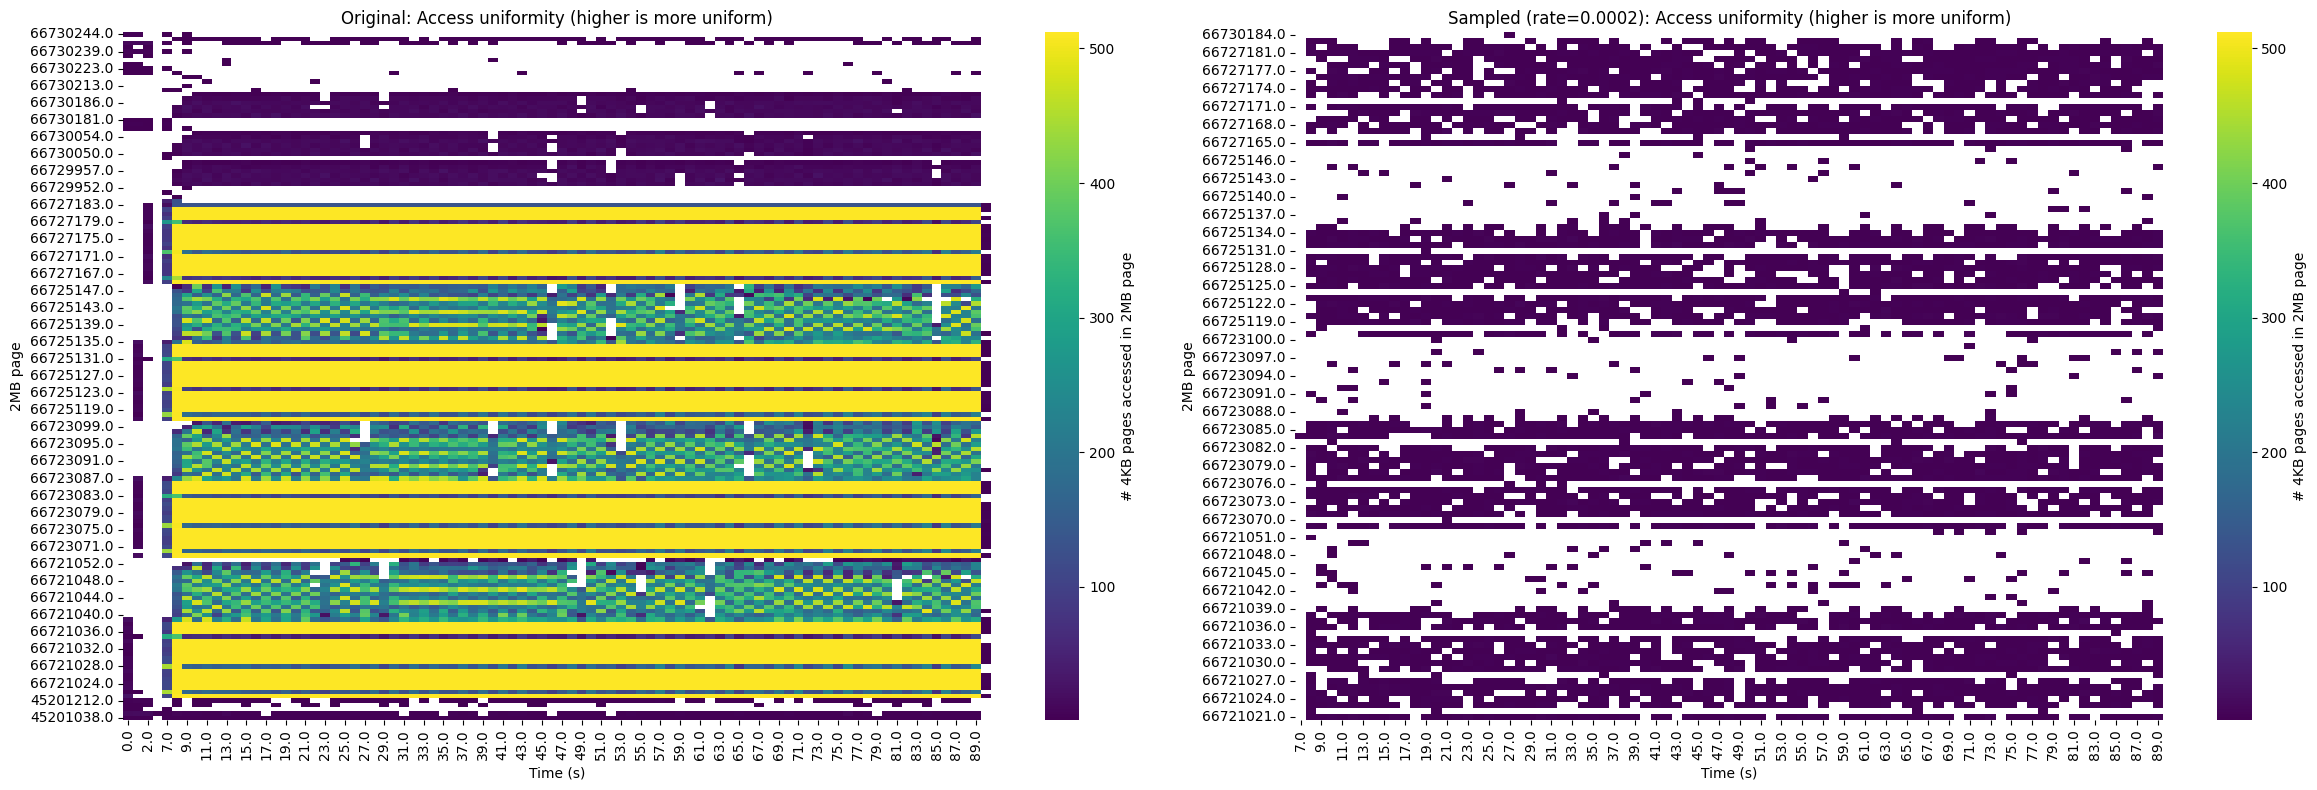

In [47]:
_ = plot_skewness_comparison(df, sample_rate=0.0002)

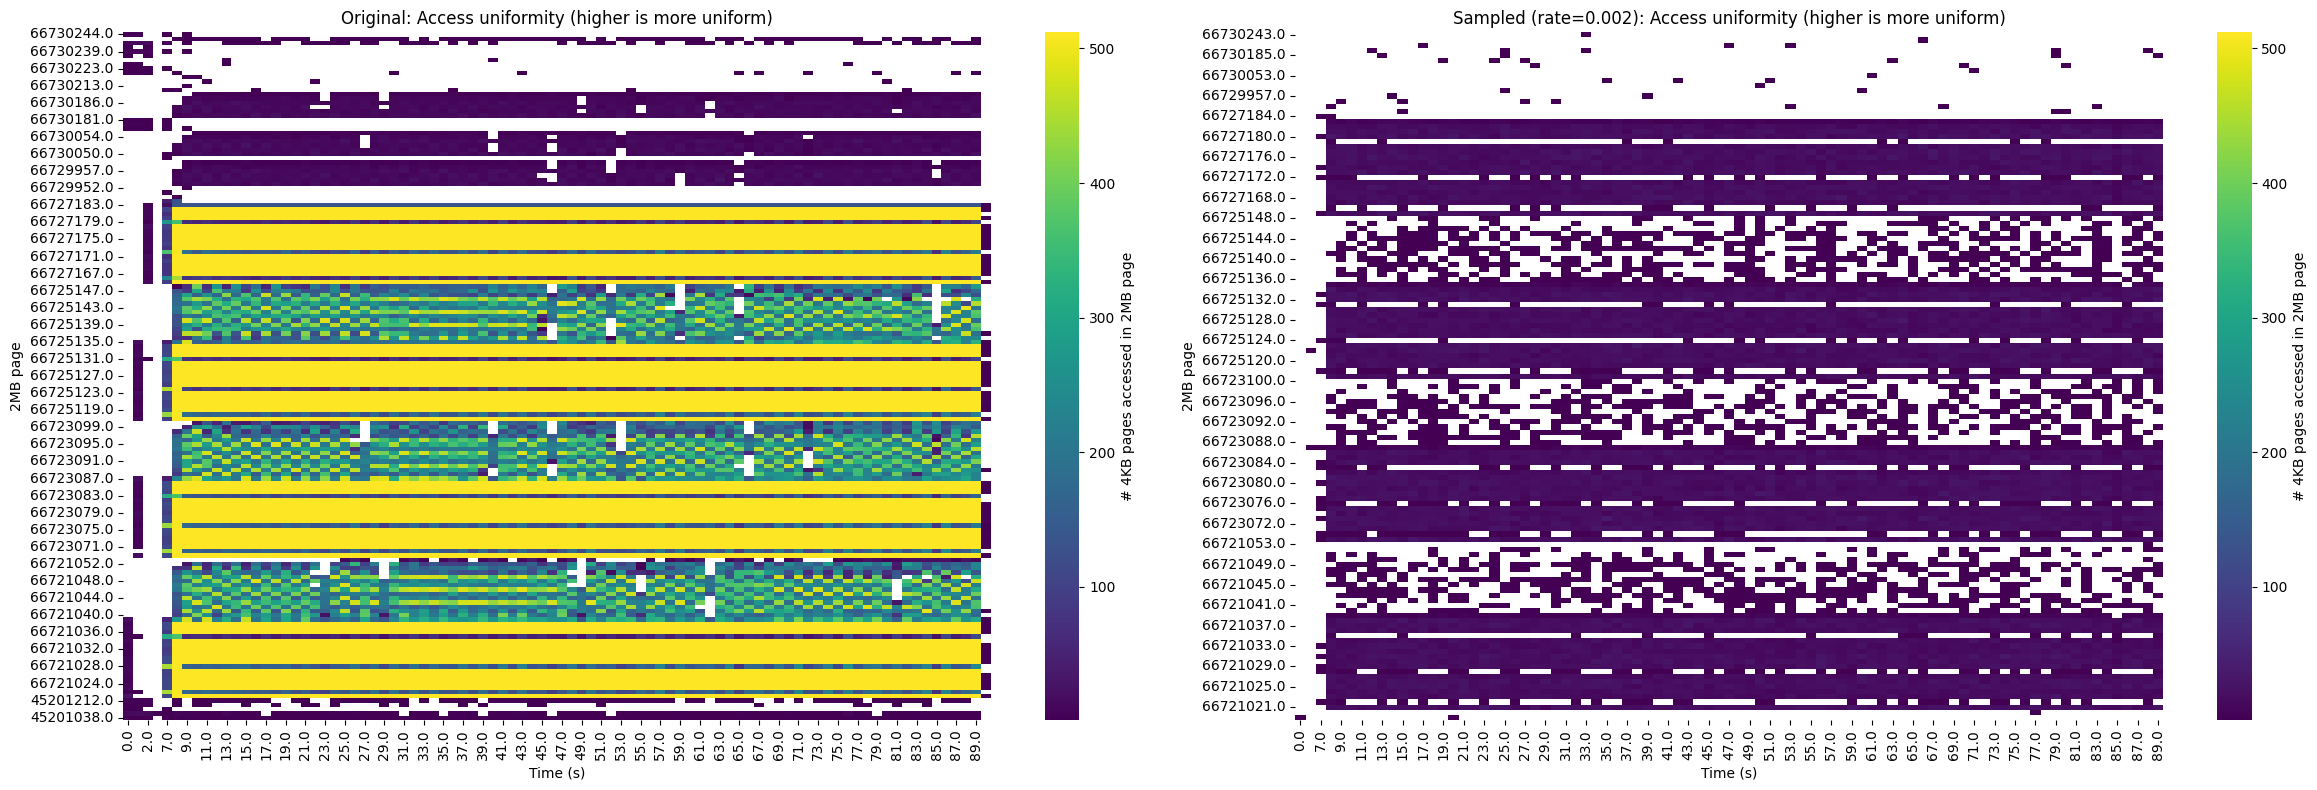

In [48]:
_ = plot_skewness_comparison(df, sample_rate=0.002)

## Plot hotness + skewness

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import LinearSegmentedColormap

def plot_hot_skewness(df, x_col='second', y_col='page_2mb', value_col='page_4k', 
                      n_bins=3, figsize_bivariate=(12, 8), figsize_separate=(16, 6),
                      show_separate=True, save_path=None, legend_position='outside'):
    """
    Create a bivariate heatmap visualization showing both access count and access uniformity.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data with at least three columns.
    x_col : str, default='second'
        Column name for the x-axis of the heatmap (typically time-based).
    y_col : str, default='page_2mb'
        Column name for the y-axis of the heatmap (typically a page identifier).
    value_col : str, default='page_4k'
        Column name used to calculate uniformity (number of unique values).
    n_bins : int, default=3
        Number of bins to divide each metric into for the bivariate color map.
    figsize_bivariate : tuple, default=(12, 8)
        Figure size for the bivariate heatmap.
    figsize_separate : tuple, default=(16, 6)
        Figure size for the separate heatmaps visualization.
    show_separate : bool, default=True
        Whether to show the separate heatmaps for individual metrics.
    save_path : str or None, default=None
        If provided, save the figures to this path prefix (will append _bivariate.png and _separate.png).
    legend_position : str, default='outside'
        Position of the 2D legend. Options: 'outside', 'inside', 'none'.
    
    Returns:
    --------
    figs : list
        List of matplotlib Figure objects created.
    """
    # Step 1: Calculate the two metrics for each (x_col, y_col) pair
    # 1. Access count - number of rows for each pair
    access_count = df.groupby([x_col, y_col]).size().reset_index(name='count')
    
    # 2. Access uniformity - number of unique value_col values for each pair
    access_uniformity = df.groupby([x_col, y_col])[value_col].nunique().reset_index(name='unique_values')
    
    # Cap the uniformity value at 512
    access_uniformity['unique_values'] = access_uniformity['unique_values'].clip(upper=512)
    
    # Merge the two metrics into a single dataframe
    combined = pd.merge(access_count, access_uniformity, on=[x_col, y_col])
    
    # Step 2: Normalize the metrics to a 0-1 scale for color mapping
    if len(combined) > 1:  # Avoid division by zero if there's only one group
        combined['count_norm'] = (combined['count'] - combined['count'].min()) / (combined['count'].max() - combined['count'].min())
        # For uniformity, normalize against 512 as the maximum value
        combined['unique_norm'] = combined['unique_values'] / 512
    else:
        combined['count_norm'] = 0.5  # Default to middle value if only one group
        combined['unique_norm'] = 0.5
    
    # Step 3: Create bins for the bivariate color mapping
    try:
        combined['count_bin'] = pd.qcut(combined['count_norm'], n_bins, labels=range(n_bins))
    except ValueError:  # Handle case where all values are identical
        combined['count_bin'] = pd.Series(np.zeros(len(combined))).astype(int)
    
    try:
        combined['unique_bin'] = pd.qcut(combined['unique_norm'], n_bins, labels=range(n_bins))
    except ValueError:  # Handle case where all values are identical
        combined['unique_bin'] = pd.Series(np.zeros(len(combined))).astype(int)
    
    combined['color_idx'] = combined['count_bin'].astype(int) * n_bins + combined['unique_bin'].astype(int)
    
    # Pivot the data for the heatmap (using color_idx for coloring)
    pivot_table = combined.pivot_table(
        values='color_idx', 
        index=y_col, 
        columns=x_col, 
        aggfunc='first'
    )
    pivot_table = pivot_table.sort_index(ascending=False)
    
    # Create pivot tables for the separate metrics
    pivot_count = combined.pivot_table(values='count', index=y_col, columns=x_col, aggfunc='first').sort_index(ascending=False)
    pivot_unique = combined.pivot_table(values='unique_values', index=y_col, columns=x_col, aggfunc='first').sort_index(ascending=False)
    
    # Create a list to store the figure objects
    figs = []
    
    # Step 4: Create a bivariate colormap
    # For a 3x3 grid (default):
    # - Horizontal axis (left to right): increasing access count
    # - Vertical axis (bottom to top): increasing access uniformity
    if n_bins == 3:
        cmap_data = np.array([
            [(1.0, 1.0, 1.0), (1.0, 0.7, 0.7), (1.0, 0.3, 0.3)],  # Low uniformity
            [(0.7, 0.7, 1.0), (0.8, 0.6, 0.8), (0.8, 0.3, 0.5)],  # Medium uniformity
            [(0.3, 0.3, 1.0), (0.5, 0.3, 0.8), (0.5, 0.0, 0.5)]   # High uniformity
        ])
    else:
        # Generate a more generic colormap for different n_bins
        # Create a gradient from white to red for count
        # and from white to blue for uniformity, then combine
        count_cmap = plt.cm.get_cmap('Reds', n_bins)
        uniq_cmap = plt.cm.get_cmap('Blues', n_bins)
        
        cmap_data = np.zeros((n_bins, n_bins, 3))
        for i in range(n_bins):
            for j in range(n_bins):
                # Blend the colors from the two cmaps
                count_color = np.array(count_cmap(i / (n_bins - 1 if n_bins > 1 else 1))[:3])
                uniq_color = np.array(uniq_cmap(j / (n_bins - 1 if n_bins > 1 else 1))[:3])
                cmap_data[j, i] = (count_color + uniq_color) / 2
    
    # Reshape the colormap data to match the expected format
    cmap_data = cmap_data.reshape(-1, 3)
    
    # Create a custom colormap
    n_colors = n_bins * n_bins
    custom_cmap = colors.ListedColormap(cmap_data)
    
    # Step 5: Plot the bivariate heatmap
    fig1, ax1 = plt.subplots(figsize=figsize_bivariate)
    figs.append(fig1)
    
    # Plot the heatmap
    im = ax1.imshow(pivot_table, cmap=custom_cmap, aspect='auto', interpolation='nearest')
    
    # Instead of a colorbar, create a 2D matrix legend
    # Remove the heatmap colorbar
    # cbar = plt.colorbar(im, ax=ax1, ticks=np.arange(0, n_colors) + 0.5)
    
    # Add a separate legend axis - positioned in the upper right corner but not overlapping
    # Adjust these coordinates to position the legend properly [left, bottom, width, height]
    legend_size = 0.2  # Size relative to main figure
    legend_ax = fig1.add_axes([1.05, 0.7, legend_size, legend_size], frameon=True)
    
    # Create a grid for the legend
    legend_grid = np.zeros((n_bins, n_bins))
    for i in range(n_bins):
        for j in range(n_bins):
            legend_grid[n_bins - j - 1, i] = i * n_bins + j
    
    # Create the legend as a small heatmap
    legend_im = legend_ax.imshow(legend_grid, cmap=custom_cmap, aspect='equal', interpolation='nearest')
    
    # Calculate the bin ranges for access count
    max_count = combined['count'].max()
    count_bin_edges = np.linspace(0, max_count, n_bins+1)
    
    # Calculate the bin ranges for uniformity (0-512)
    uniformity_bin_edges = np.linspace(0, 512, n_bins+1)
    
    # Create labels for the legend based on actual value ranges
    if n_bins == 3:
        count_labels = [
            f"Low: 0-{count_bin_edges[1]:.0f}",
            f"Med: {count_bin_edges[1]:.0f}-{count_bin_edges[2]:.0f}",
            f"High: {count_bin_edges[2]:.0f}+"
        ]
        
        uniformity_labels = [
            f"Low: 0-{uniformity_bin_edges[1]:.0f}",
            f"Med: {uniformity_bin_edges[1]:.0f}-{uniformity_bin_edges[2]:.0f}",
            f"High: {uniformity_bin_edges[2]:.0f}-512"
        ]
    else:
        count_labels = [f"Level {i+1}: {count_bin_edges[i]:.0f}-{count_bin_edges[i+1]:.0f}" 
                      if i < n_bins-1 else f"Level {i+1}: {count_bin_edges[i]:.0f}+" 
                      for i in range(n_bins)]
        
        uniformity_labels = [f"Level {i+1}: {uniformity_bin_edges[i]:.0f}-{uniformity_bin_edges[i+1]:.0f}" 
                          for i in range(n_bins)]
        uniformity_labels[-1] = f"Level {n_bins}: {uniformity_bin_edges[-2]:.0f}-512"
    
    # X-axis = count
    legend_ax.set_xticks(np.arange(n_bins))
    legend_ax.set_xticklabels([f"{i+1}" for i in range(n_bins)], fontsize=7)
    legend_ax.set_xlabel('Access Count', fontsize=8)
    
    # Y-axis = uniformity (note: reversed to match the orientation of the main heatmap)
    legend_ax.set_yticks(np.arange(n_bins))
    legend_ax.set_yticklabels([f"{i+1}" for i in range(n_bins-1, -1, -1)], fontsize=7)  # Reversed to match visual arrangement
    legend_ax.set_ylabel('Uniformity', fontsize=8)
    
    # Adjust tick parameters
    legend_ax.tick_params(axis='both', which='major', labelsize=8)
    legend_ax.tick_params(axis='both', which='minor', labelsize=6)
    
    # Add grid to the legend for better visual separation
    legend_ax.grid(True, color='white', linestyle='-', linewidth=0.5)
    legend_ax.set_title('Legend', fontsize=9)
    
    # Add labels and title
    ax1.set_xlabel(x_col.capitalize())
    # ax1.set_ylabel(y_col.capitalize())
    ax1.set_title('Bivariate Heatmap: Page Access Count and Uniformity')
    
    # Format ticks for better readability
    x_ticks = ax1.get_xticks().astype(int)
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels([
        str(int(pivot_table.columns[i])) if i < len(pivot_table.columns) and i >= 0 else '' 
        for i in x_ticks
    ])
    
    # Add a description of the levels below the legend
    fig1.text(1.05, 0.55, "Access Count:", fontsize=8, fontweight='bold')
    for i, label in enumerate(count_labels):
        fig1.text(1.05, 0.52 - i*0.03, label, fontsize=7)
    
    fig1.text(1.05, 0.38, "Uniformity (max 512):", fontsize=8, fontweight='bold')
    for i, label in enumerate(uniformity_labels):
        fig1.text(1.05, 0.35 - i*0.03, label, fontsize=7)
    
    # Add a descriptive title with explanation
    ax1.set_title('Bivariate Heatmap: Page Access Pattern\n' +
                 'Color shows relationship between access count and uniformity (max 512)', fontsize=10)
    
    plt.grid(False)
    plt.tight_layout()
    
    # Save the bivariate heatmap if requested
    if save_path:
        plt.savefig(f"{save_path}_bivariate.png", dpi=300, bbox_inches='tight')
    
    # Step 6: Create separate heatmaps for each metric if requested
    if show_separate:
        fig2, (ax2, ax3) = plt.subplots(1, 2, figsize=figsize_separate)
        figs.append(fig2)
        
        # Plot count heatmap
        im1 = ax2.imshow(pivot_count, cmap='Reds', aspect='auto')
        plt.colorbar(im1, ax=ax2, label='Access Count')
        ax2.set_xlabel(x_col.capitalize())
        # ax2.set_ylabel(y_col.capitalize())
        ax2.set_title('Access Count Heatmap')
        
        # Plot uniformity heatmap with explicit max of 512
        im2 = ax3.imshow(pivot_unique, cmap='Blues', aspect='auto', vmax=512)
        cbar = plt.colorbar(im2, ax=ax3, label=f'Unique {value_col} Values (Uniformity, max 512)')
        # Make sure the colorbar ticks reflect the 0-512 range
        cbar.set_ticks(np.linspace(0, 512, 6))
        ax3.set_xlabel(x_col.capitalize())
        # ax3.set_ylabel(y_col.capitalize())
        ax3.set_title('Access Uniformity Heatmap (0-512)')
        
        plt.tight_layout()
        
        # Save the separate heatmaps if requested
        if save_path:
            plt.savefig(f"{save_path}_separate.png", dpi=300, bbox_inches='tight')
    
    plt.show()
    return figs

/tmp/ipykernel_234263/873539975.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


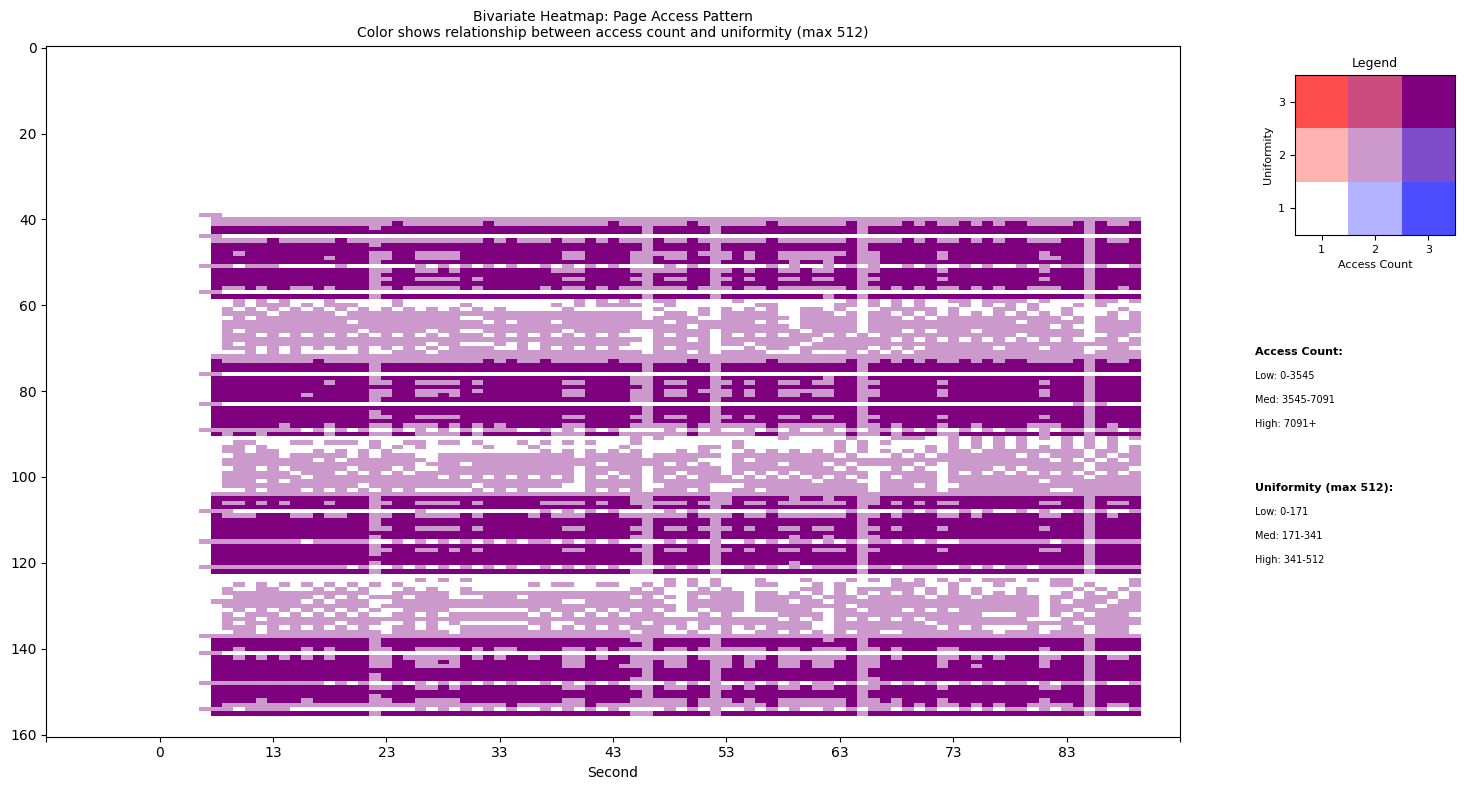

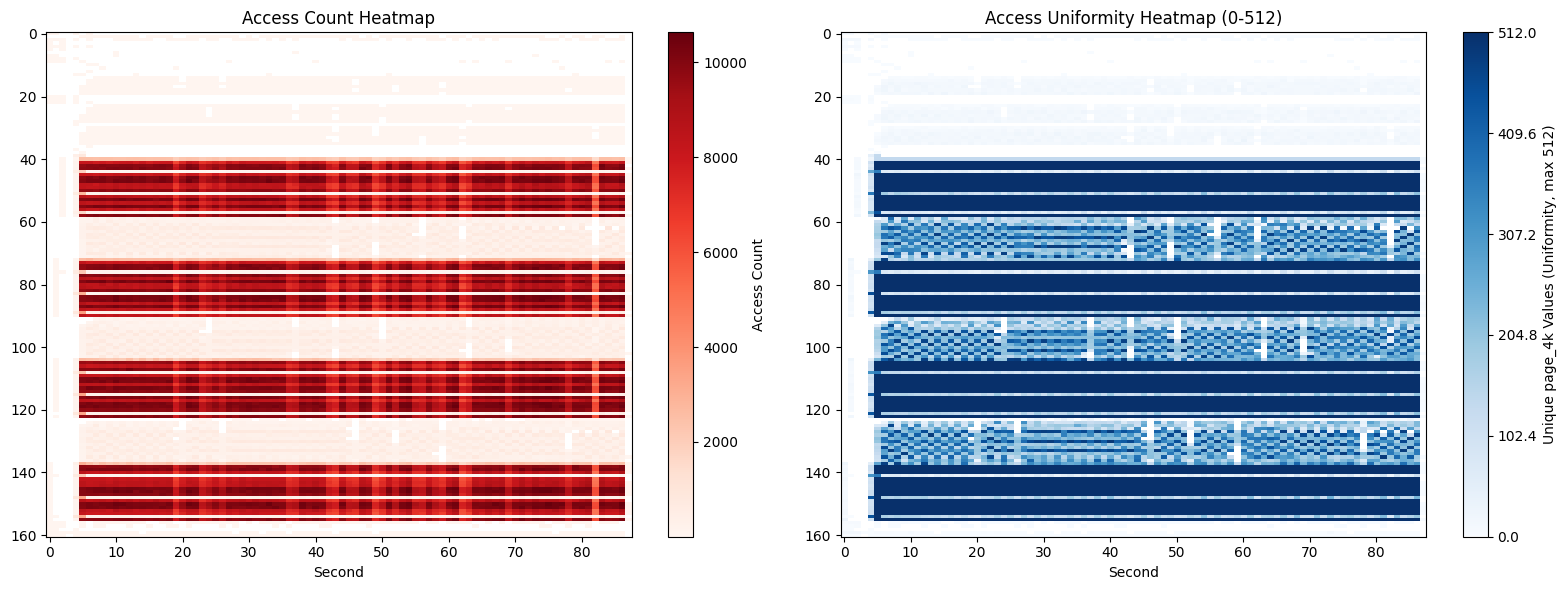

In [50]:
_ = plot_hot_skewness(df)

In [19]:
def draw_uniformity_hist_with_heat(df, x_col='second', y_col='page_2mb', value_col='page_4k'):
    access_count = df.groupby([x_col, y_col]).size().reset_index(name='count')
    
    # 2. Access uniformity - number of unique value_col values for each pair
    access_uniformity = df.groupby([x_col, y_col])[value_col].nunique().reset_index(name='unique_values')
    
    # Cap the uniformity value at 512
    access_uniformity['unique_values'] = access_uniformity['unique_values'].clip(upper=512)
    
    # Merge with access_count to get the count for each (x_col, y_col) pair
    merged_data = pd.merge(access_uniformity, access_count, on=[x_col, y_col])
    
    # Create bin edges
    bin_edges = np.linspace(0, 512, 33)
    
    # Create figure and axes explicitly
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # Find which bin each point belongs to
    bin_indices = np.digitize(merged_data['unique_values'], bin_edges) - 1
    
    # Calculate average count per bin
    bin_counts = np.zeros(len(bin_edges) - 1)
    bin_frequencies = np.zeros(len(bin_edges) - 1)
    
    for idx, bin_idx in enumerate(bin_indices):
        if 0 <= bin_idx < len(bin_counts):
            bin_counts[bin_idx] += merged_data['count'].iloc[idx]
            bin_frequencies[bin_idx] += 1
    
    # Calculate average for bins with non-zero frequencies
    avg_counts = np.zeros(len(bin_edges) - 1)
    for i in range(len(bin_counts)):
        if bin_frequencies[i] > 0:
            avg_counts[i] = bin_counts[i] / bin_frequencies[i]
    
    # Use log normalization for the colormap
    from matplotlib.colors import LogNorm
    
    # Add a small epsilon to avoid log(0)
    epsilon = 1e-10
    log_norm = LogNorm(vmin=max(avg_counts.min(), epsilon), vmax=max(avg_counts.max(), epsilon))
    
    # Histogram with colormapped bins
    n, bins, patches = ax.hist(merged_data['unique_values'], bins=bin_edges, 
                              edgecolor='black', alpha=0.7)
    
    # Color the bins according to the average count using log scale
    cmap = plt.cm.viridis  # Can use different colormaps: plasma, inferno, magma, etc.
    for i in range(len(patches)):
        if avg_counts[i] > 0:  # Only color bins with non-zero counts
            patches[i].set_facecolor(cmap(log_norm(max(avg_counts[i], epsilon))))
    
    # Add a colorbar for reference with log scale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=log_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, label='Average Access Count (log scale)')
    
    # Add labels and title
    ax.set_xlabel('Number of Unique Values')
    ax.set_ylabel('Frequency')
    ax.set_title('Access Uniformity Distribution (0-512)')
    
    # Set x-axis range
    ax.set_xlim(0, 512)
    
    # Add grid for better readability
    ax.grid(alpha=0.3)
    
    # Display the plot
    plt.tight_layout()
    plt.show()

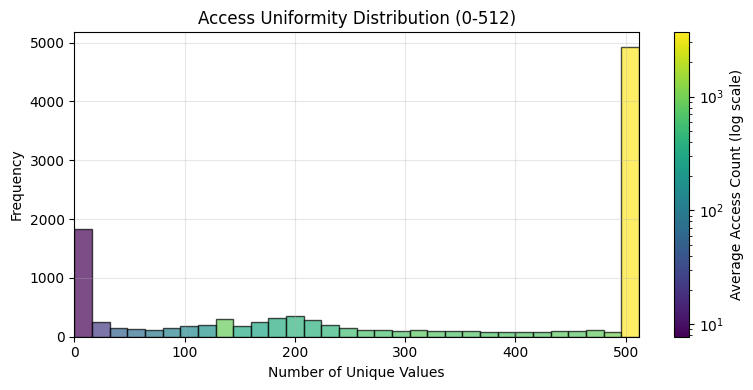

In [20]:
draw_uniformity_hist_with_heat(df)

In [32]:
def draw_uniformity_hist(df, x_col='second', y_col='page_2mb', value_col='page_4k'):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib.patches import Rectangle
    import pandas as pd
    
    # Count accesses for each page
    access_count = df.groupby([x_col, y_col]).size().reset_index(name='count')
    
    # Calculate uniformity - number of unique value_col values for each page
    access_uniformity = df.groupby([x_col, y_col])[value_col].nunique().reset_index(name='unique_values')
    
    # Cap the uniformity value at 512
    access_uniformity['unique_values'] = access_uniformity['unique_values'].clip(upper=512)
    
    # Merge with access_count to get the count for each page
    merged_data = pd.merge(access_uniformity, access_count, on=[x_col, y_col])
    
    # Create bin edges
    bin_edges = np.linspace(0, 512, 33)
    num_bins = len(bin_edges) - 1
    
    # Create figure and axes
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Set a light gray background to help with contrast
    ax.set_facecolor('#f8f8f8')
    
    # Find which bin each point belongs to
    merged_data['bin_idx'] = np.digitize(merged_data['unique_values'], bin_edges) - 1
    
    # Create a list to store access counts for each bin
    bin_access_counts = [[] for _ in range(num_bins)]
    
    # Group access counts by bin
    for _, row in merged_data.iterrows():
        bin_idx = int(row['bin_idx'])  # Convert to integer
        if 0 <= bin_idx < num_bins:
            bin_access_counts[bin_idx].append(row['count'])
            
    # Calculate traditional histogram for bin heights
    hist_counts, _ = np.histogram(merged_data['unique_values'], bins=bin_edges)
    
    # Create a colormap for the heatmap
    cmap = plt.cm.viridis
    
    # Use log scale for better visualization of access counts
    log_norm = mcolors.LogNorm(
        vmin=max(1, merged_data['count'].min()),  # Avoid log(0)
        vmax=max(merged_data['count'].max(), 1)
    )
    
    # Maximum height of the bars
    max_bar_height = max(hist_counts) if max(hist_counts) > 0 else 1
    
    # Bin width
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Draw each bin with individual page access counts
    for bin_idx in range(num_bins):
        # Get access counts for this bin and sort them
        bin_counts = sorted(bin_access_counts[bin_idx])
        
        # Skip empty bins
        if not bin_counts:
            continue
            
        # Bin position
        bin_left = bin_edges[bin_idx]
        
        # Get height for this bin (traditional histogram height)
        bin_height = hist_counts[bin_idx]
        
        # Draw base histogram outline with thicker border
        ax.add_patch(Rectangle(
            (bin_left, 0), 
            bin_width, 
            bin_height,
            fill=False,
            edgecolor='black',
            linewidth=1.5,
            zorder=10  # Ensure borders appear on top
        ))
        
        # Draw individual page access counts as colored strips
        # Calculate the height of each strip
        strip_height = bin_height / len(bin_counts) if len(bin_counts) > 0 else 0
        
        for i, count in enumerate(bin_counts):
            # Bottom position of this strip
            bottom = i * strip_height
            
            # Color based on access count (log scale)
            color = cmap(log_norm(max(count, 1)))
            
            # Add the colored strip (with reduced alpha for better border visibility)
            ax.add_patch(Rectangle(
                (bin_left, bottom), 
                bin_width, 
                strip_height,
                facecolor=color,
                edgecolor=None,
                alpha=0.7,
                zorder=5  # Below the border
            ))
    
    # Set up the colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=log_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, label='Page Access Count (log scale)')
    
    # Add labels and title
    ax.set_xlabel('# 4KiB pages accessed in a 2MiB huge page')
    ax.set_ylabel('Frequency')
    ax.set_title('Page Access Uniformity and Access Counts')
    
    # Set axis limits
    ax.set_xlim(0, 512)
    ax.set_ylim(0, max_bar_height * 1.05)  # Add 5% padding at the top
    
    # Add grid for better readability
    ax.grid(alpha=0.3)
    
    # Display the plot
    plt.tight_layout()
    plt.show()
    
    return fig

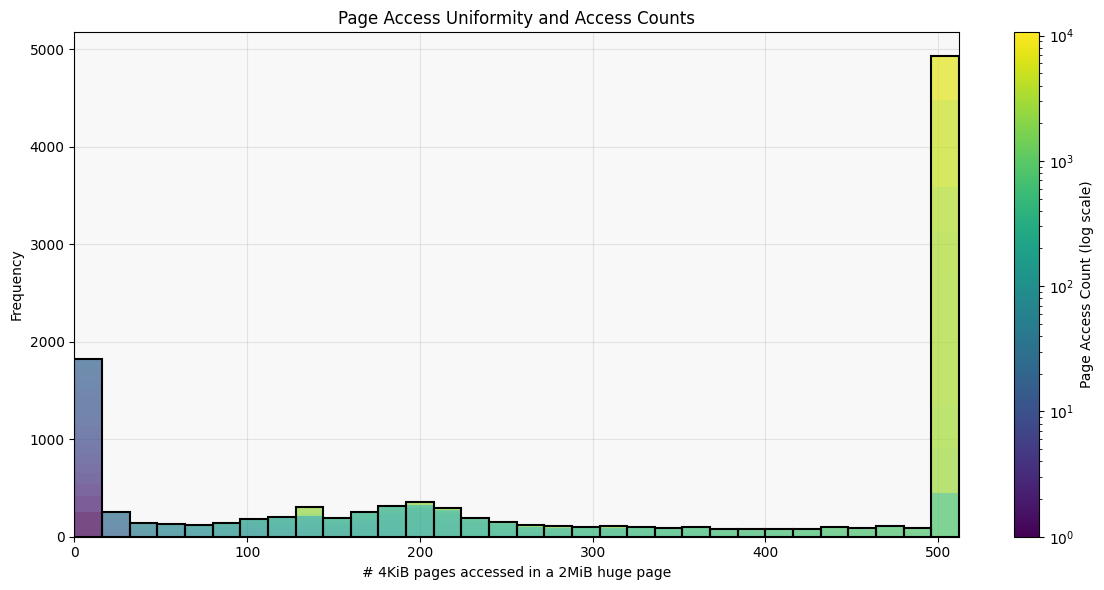

In [33]:
_ = draw_uniformity_hist(df)